In [86]:
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(ggplot2)
library(patchwork)
library(hdf5r)
library(future)
library(RColorBrewer)
library(dplyr)
library(Matrix)
library(BSgenome.Hsapiens.UCSC.hg38)
library(glue)
library(harmony)
library(matrixStats)
library(scales)
library(biomaRt)
library(curl)
library(goseq)
library(httr)
library(Scillus)
library(TFBSTools)
library(JASPAR2020)
library(ggridges)
library(ggrepel)
library(ggsignif)
library(qusage)
library(tidyverse)
library(cowplot)
library(forestmodel)
library(pheatmap)
httr::set_config(config(ssl_verifypeer = 0L))
set.seed(1234)
setwd("/home/jupyter/scATAC_analysis/edit/snatac-rcc-manuscript")
source("scripts/functions.r")


# Figure S5A: Coverage plots at immune recruiting loci with increased accessibility in BAP1 mutant tumor cells

Significant DAGs between BAP1 pLOF and WT ccRCC tumor cells in supp table 5A

## Read in genes differentially accessible between BAP1 mutated and BAP1 wt ccrcc-balanced tumor cells and subset to those that are immune cell recruiting. 

In [ ]:
dag <- readRDS("processed_data/ccrcc_balanced_bap1_DAGs.rds")

chemokines <- c("CXCL9", "CXCL10", "CXCL11", "CXCL12", "CCL5", "CCL2", "CCL4", "CCL20", "CCL17", "CCL22", "CSF1")
sig_chemokine_dags <- dag %>% filter(cluster == "pLOF", gene %in% chemokines, p_val_adj < 0.05)


## Read in downsampled tumor cell object and make coverage plots

*Note: Created in `manuscript-figure5.ipynb`*

ccrcc-balanced tumor cells from late stage ccRCC patients, BAP1 WT or with pLOF mutation. Downsampled to max 1000 tumor cells per sample. 

In [ ]:
ccrcc_downsample <- readRDS("processed_data/ccrcc_balanced_bap1_mut_wt_latestage_downsamplebiopsy1000.rds")


Warning message:
"Removed 105 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


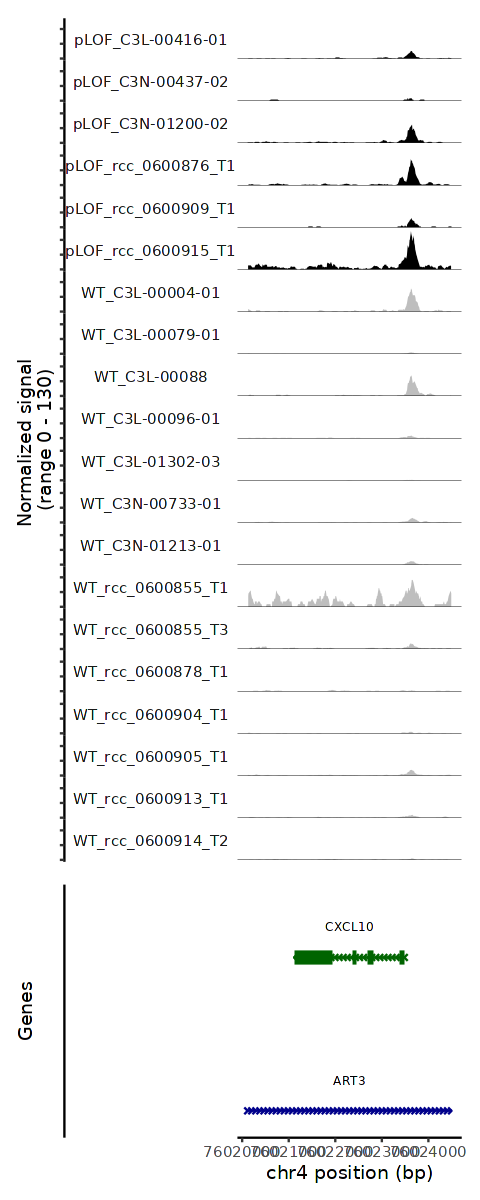

Warning message:
"Removed 105 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


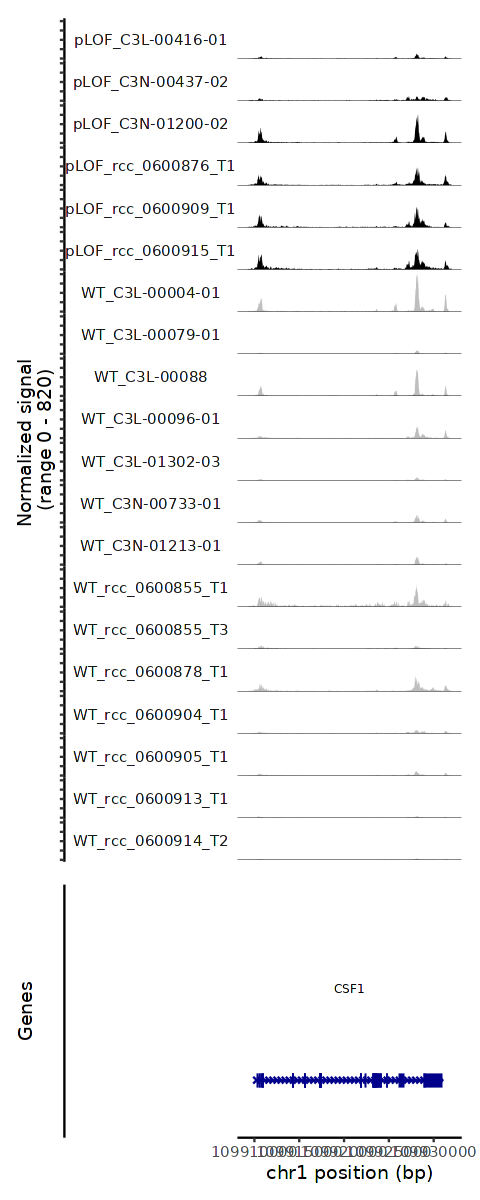

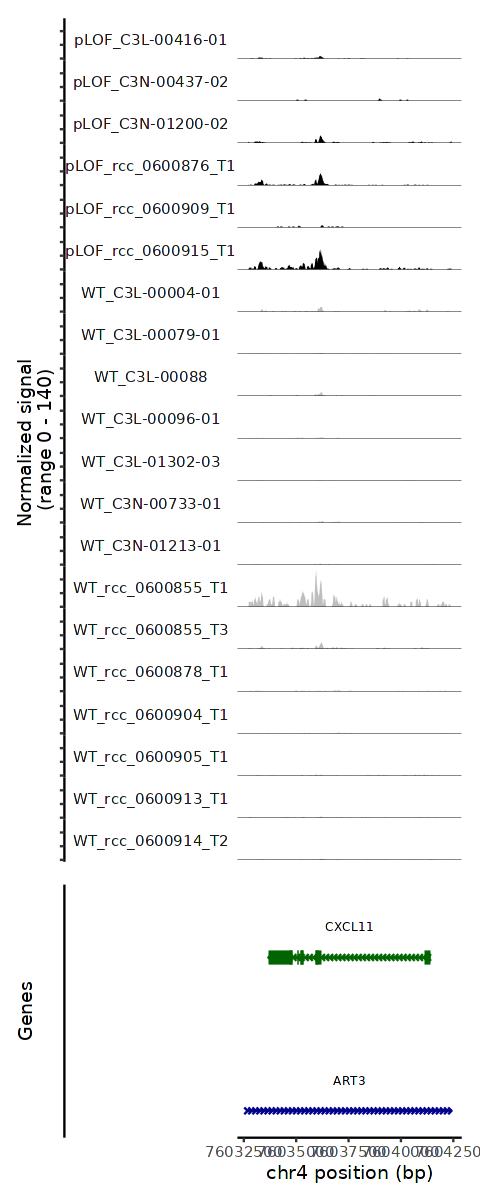

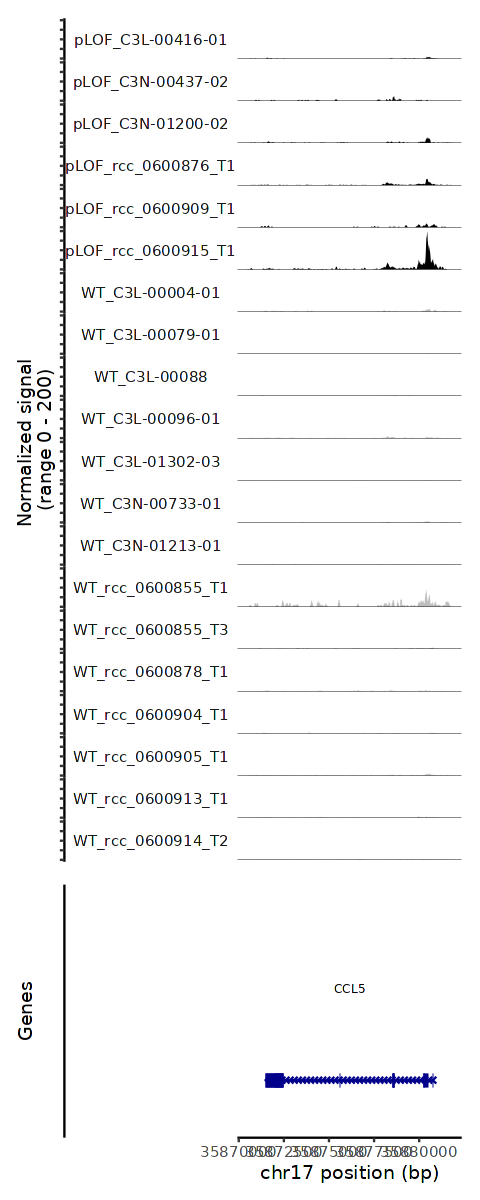

In [5]:
sig_chemokine_dags_genes <- sig_chemokine_dags$gene
for (gene in sig_chemokine_dags_genes) {
    DefaultAssay(ccrcc_downsample) <- "ATAC"
    options(repr.plot.width = 4, repr.plot.height = 10)
    plot <- CoveragePlot(ccrcc_downsample, region = gene, peaks = F, group.by = "biopsy", split.by = "BAP1", extend.upstream = 1000, extend.downstream = 1000) & scale_fill_manual(values = c(rep("black", 6), rep("grey", 14)))
    print(plot)
}


# Figure S5B: Boxplots of broad immune cell type proporations in BAP1 pLOF vs WT tumors, restricted to those without sarcomatoid features

## Read in all cells seurat object metadata and filter
Filter to cells to QC-passing from patients with late stage clear cell ccRCC. And those that have a pLOF BAP1 mutation or are BAP1 wt. 

In [6]:
metadata <- readRDS("processed_data/allcells_seurat_metadata.rds")

metadata <- metadata %>% filter((BAP1_LOF == 1) | (BAP1 == 0))
metadata <- metadata %>% filter((broad_celltype_excluded != "Excluded") & (stage %in% c("3", "4")) & (histology == "Clear cell"))
metadata$BAP1_status <- ifelse(metadata$BAP1_LOF == 1, "pLOF", "WT")


## Calculate immune cell type proportion

In [7]:
# Grouping by cell type, biopsy, and BAP1 status
grouped_df <- metadata %>%
  group_by(broad_celltype_excluded, biopsy, BAP1_status, sarcomatoid_features) %>%
  summarise(cell_count = n(), .groups = "drop")

# Calculating total cells per biopsy
total_cells_per_biopsy <- grouped_df %>%
  group_by(biopsy) %>%
  summarise(total_cells = sum(cell_count), .groups = "drop")

# Merging to get total cells in each biopsy alongside each group
merged_df <- merge(grouped_df, total_cells_per_biopsy, by = "biopsy")

# Calculating the proportion
merged_df <- merged_df %>%
  mutate(proportion = cell_count / total_cells)

# Selecting relevant columns
all_everything_props <- merged_df %>%
  dplyr::select(biopsy, broad_celltype_excluded, BAP1_status, sarcomatoid_features, proportion, total_cells)


Set immune cell type order and only plot immune cell types

In [8]:
all_everything_props$BAP1_status <- factor(all_everything_props$BAP1_status, levels = c("WT", "pLOF"))
immune_infiltrate_plot <- all_everything_props %>% filter(!(broad_celltype_excluded %in% c("Tumor", "Endothelial", "Perivascular cell", "Fibroblast")))
immune_infiltrate_plot$broad_celltype_excluded <- factor(immune_infiltrate_plot$broad_celltype_excluded,
    levels = rev(c("CD8 T cell", "T-helper", "T-reg", "NK", "Plasma cell", "B cell", "TAM", "Monocyte", "MoDC", "cDC"))
)


Readable labels for saromatoid features

In [9]:
immune_infiltrate_plot <- immune_infiltrate_plot %>%
  mutate(sarcomatoid_features = case_when(
    sarcomatoid_features == 0 ~ "absent",
    sarcomatoid_features == 1 ~ "present",
    is.na(sarcomatoid_features) ~ "no information"
  ))


## Subset to those without sarcomatoid features

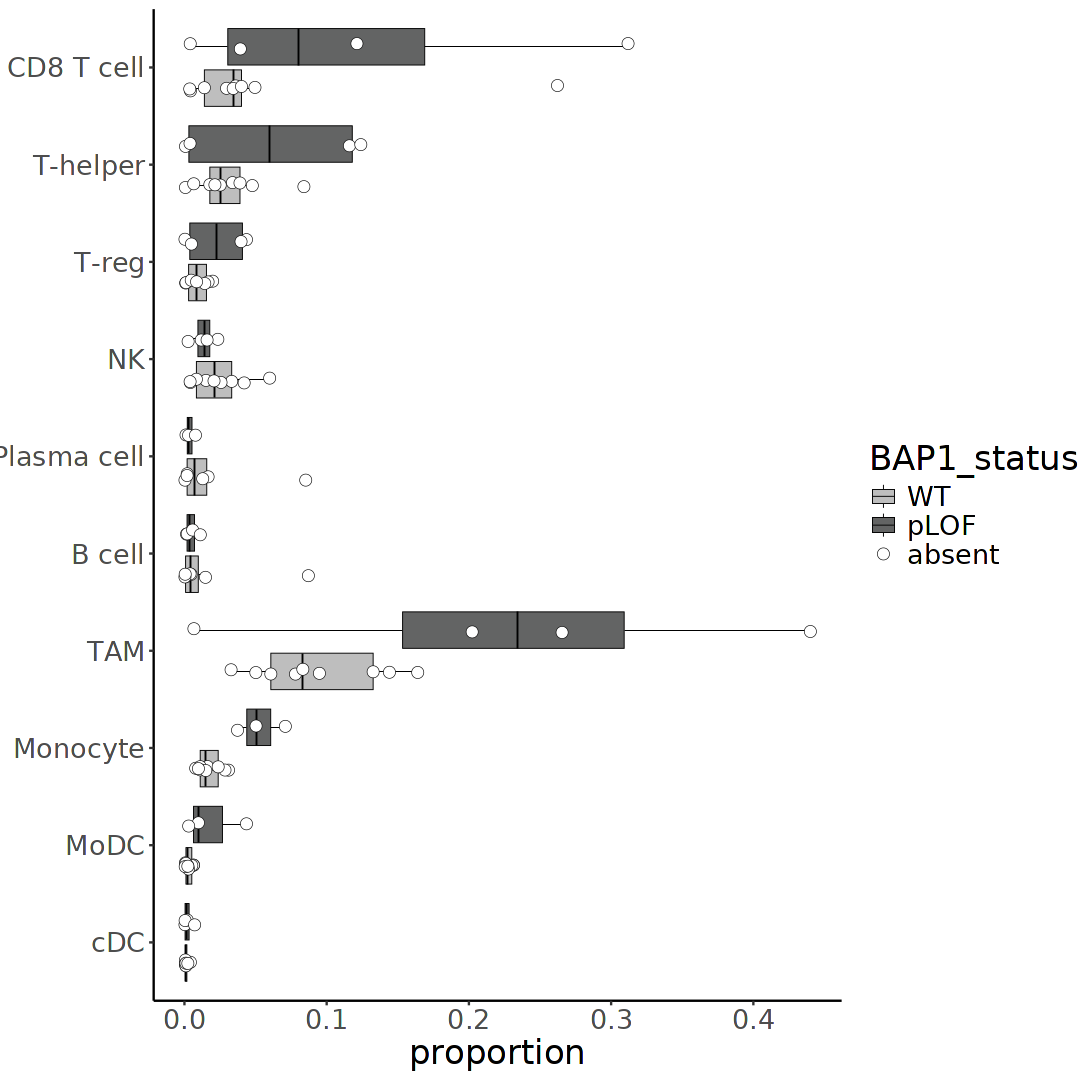

In [10]:
options(repr.plot.width = 9, repr.plot.height = 9)

immune_infiltrate_plot %>%
  filter(sarcomatoid_features == "absent") %>%
  ggplot(aes(x = broad_celltype_excluded, y = proportion, fill = BAP1_status)) +
  geom_boxplot(outlier.shape = NA, color = "black", lwd = 0.2, position = position_dodge(0.85)) +
  geom_point(
    position = position_jitterdodge(dodge.width = 0.85, jitter.width = 0.1),
    alpha = 1,
    aes(group = BAP1_status, fill = factor(sarcomatoid_features)),
    stroke = 0.2,
    shape = 21,
    size = 3
  ) +
  coord_flip() +
  theme_classic() +
  theme(
    text = element_text(size = 20),
    axis.title.y = element_blank()
  ) +
  scale_fill_manual(values = c("grey", "#636464", "white")) +
  scale_color_manual(values = c("black", "white"))


## Nominal and adjusted p-values for immune cell type frequency comparisons. Limiting to samples w/o sarcomatoid features

In [11]:
immune_infiltrate_plot <- immune_infiltrate_plot %>% filter(sarcomatoid_features == "absent")
celltypes <- unique(immune_infiltrate_plot$broad_celltype_excluded)
results <- list()
for (i in 1:length(celltypes)) {
    celltype <- celltypes[i]
    celltype_meta <- immune_infiltrate_plot
    celltype_meta$broad_celltype_excluded <- as.character(celltype_meta$broad_celltype_excluded)
    celltype_meta <- celltype_meta %>% filter(broad_celltype_excluded == celltype)
    bap1_mt_prop_vector <- (celltype_meta %>% filter(BAP1_status == "pLOF"))$proportion
    bap1_wt_prop_vector <- (celltype_meta %>% filter(BAP1_status == "WT"))$proportion
    test <- wilcox.test(x = bap1_mt_prop_vector, y = bap1_wt_prop_vector)
    side <- ifelse(median(bap1_mt_prop_vector) > median(bap1_wt_prop_vector), "pLOF", "WT")
    results[[i]] <- data.frame(celltype = celltype, pvalue = test$p.value, side = side)
}

results_df <- dplyr::bind_rows(results)
results_df$padjust <- p.adjust(p = results_df$pvalue, method = "fdr")
results_df


celltype,pvalue,side,padjust
<fct>,<dbl>,<chr>,<dbl>
CD8 T cell,0.413986014,pLOF,0.82517483
MoDC,0.063636364,pLOF,0.31818182
Monocyte,0.009090909,pLOF,0.09090909
NK,0.413986014,WT,0.82517483
cDC,0.808080808,pLOF,0.82517483
T-reg,0.648484848,pLOF,0.82517483
B cell,0.787878788,WT,0.82517483
Plasma cell,0.714285714,WT,0.82517483
T-helper,0.825174825,pLOF,0.82517483


# Figure S5C: Boxplots of broad immune cell type proportions between BAP1 pLOF vs WT tumors, stratified by cohort

Evaluating if the difference in immune cell proportions is consistent across cohorts. 

## Read in all cells seurat object metadata and filter
Filter to cells to QC-passing from patients with late stage clear cell ccRCC. And those that have a pLOF BAP1 mutation or are BAP1 wt. 

In [12]:
metadata <- readRDS("processed_data/allcells_seurat_metadata.rds")

metadata <- metadata %>% filter((BAP1_LOF == 1) | (BAP1 == 0))
metadata <- metadata %>% filter((broad_celltype_excluded != "Excluded") & (stage %in% c("3", "4")) & (histology == "Clear cell"))
metadata$BAP1_status <- ifelse(metadata$BAP1_LOF == 1, "pLOF", "WT")


## Calculate immune cell type proportion

In [13]:
# Grouping by cell type, biopsy, and BAP1 status
grouped_df <- metadata %>%
  group_by(broad_celltype_excluded, biopsy, BAP1_status, cohort) %>%
  summarise(cell_count = n(), .groups = "drop")

# Calculating total cells per biopsy
total_cells_per_biopsy <- grouped_df %>%
  group_by(biopsy) %>%
  summarise(total_cells = sum(cell_count), .groups = "drop")

# Merging to get total cells in each biopsy alongside each group
merged_df <- merge(grouped_df, total_cells_per_biopsy, by = "biopsy")

# Calculating the proportion
merged_df <- merged_df %>%
  mutate(proportion = cell_count / total_cells)

# Selecting relevant columns
all_everything_props <- merged_df %>%
  dplyr::select(biopsy, broad_celltype_excluded, BAP1_status, cohort, proportion, total_cells)


Set immune cell type order and only plot immune cell types

In [17]:
all_everything_props$BAP1_status <- factor(all_everything_props$BAP1_status, levels = c("WT", "pLOF"))
immune_infiltrate_plot <- all_everything_props %>% filter(!(broad_celltype_excluded %in% c("Tumor", "Endothelial", "Perivascular cell", "Fibroblast")))
immune_infiltrate_plot$broad_celltype_excluded <- factor(immune_infiltrate_plot$broad_celltype_excluded,
    levels = rev(c("CD8 T cell", "T-helper", "T-reg", "NK", "Plasma cell", "B cell", "TAM", "Monocyte", "MoDC", "cDC"))
)


Better labels for cohorts

In [18]:
immune_infiltrate_plot <- immune_infiltrate_plot %>%
  mutate(cohort = recode(cohort,
    "in-house" = "Internal",
    "wuetal" = "Wu et al Nat Comm 2023"
  ))


Function for calculating nominal and adjusted p-values for immune cell type frequency comparisons

In [19]:
run_bap1_wilcox_test <- function(df) {
    celltypes <- unique(df$broad_celltype_excluded)
    results <- list()

    for (i in seq_along(celltypes)) {
        celltype <- celltypes[i]
        celltype_meta <- df %>%
            filter(broad_celltype_excluded == celltype)

        bap1_mt_prop_vector <- filter(celltype_meta, BAP1_status == "pLOF")$proportion
        bap1_wt_prop_vector <- filter(celltype_meta, BAP1_status == "WT")$proportion

        test <- wilcox.test(x = bap1_mt_prop_vector, y = bap1_wt_prop_vector)

        side <- ifelse(median(bap1_mt_prop_vector) > median(bap1_wt_prop_vector), "pLOF", "WT")

        results[[i]] <- data.frame(
            celltype = celltype,
            pvalue = test$p.value,
            side = side
        )
    }

    results_df <- bind_rows(results)
    results_df$padjust <- p.adjust(p = results_df$pvalue, method = "fdr")
    return(results_df)
}


## Internal

In [20]:
internal <- immune_infiltrate_plot %>%
    filter(cohort == "Internal") %>%
    filter(broad_celltype_excluded %in% c("Monocyte", "TAM", "CD8 T cell"))


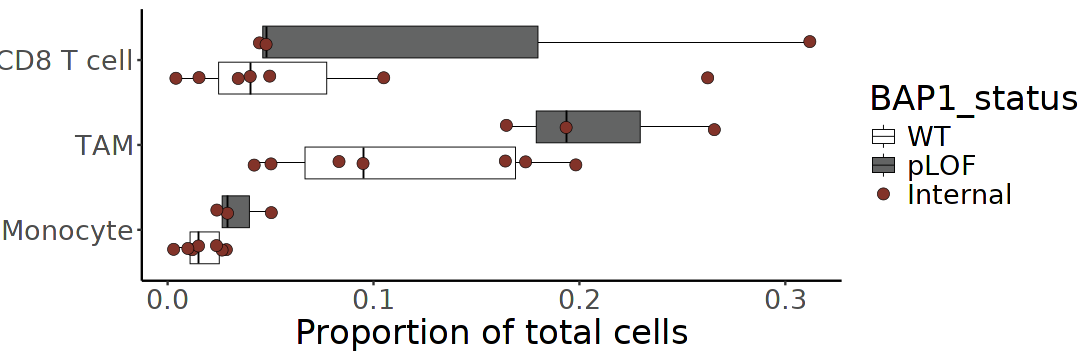

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 3)

internal %>%
  ggplot(aes(x = broad_celltype_excluded, y = proportion, fill = BAP1_status)) +
  geom_boxplot(outlier.shape = NA, color = "black", lwd = 0.2, position = position_dodge(0.85)) +
  geom_point(
    position = position_jitterdodge(dodge.width = 0.85, jitter.width = 0.1),
    alpha = 1,
    aes(group = BAP1_status, fill = factor(cohort)),
    stroke = 0.2,
    shape = 21,
    size = 3
  ) +
  coord_flip() +
  theme_classic() +
  theme(
    text = element_text(size = 20),
    axis.title.y = element_blank()
  ) +
  scale_fill_manual(values = c("white", "#636464", "#823329")) +
  scale_color_manual(values = c("black", "white")) +
  ylab("Proportion of total cells")


In [22]:
run_bap1_wilcox_test(internal)


celltype,pvalue,side,padjust
<fct>,<dbl>,<chr>,<dbl>
CD8 T cell,0.38333333,pLOF,0.3833333
TAM,0.11666667,pLOF,0.1750000
Monocyte,0.06666667,pLOF,0.1750000


## Wu et al

In [23]:
wuetal <- immune_infiltrate_plot %>%
    filter(cohort == "Wu et al Nat Comm 2023") %>%
    filter(broad_celltype_excluded %in% c("Monocyte", "TAM", "CD8 T cell"))


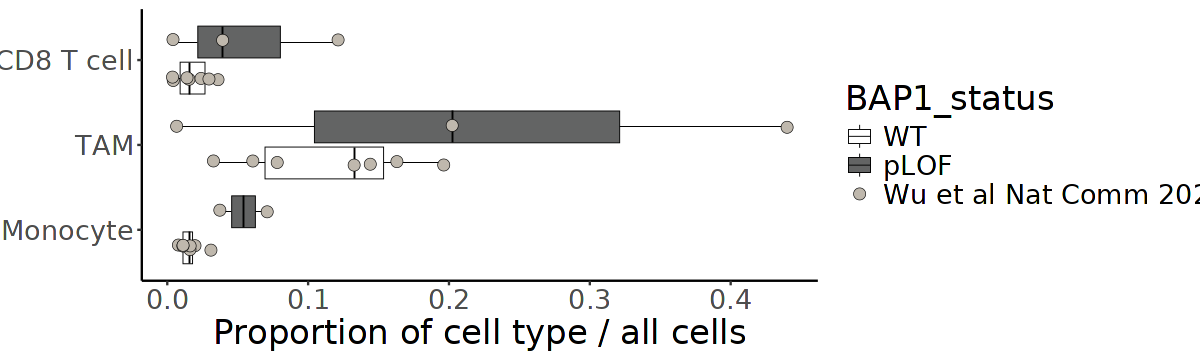

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 3)

wuetal %>%
  ggplot(aes(x = broad_celltype_excluded, y = proportion, fill = BAP1_status)) +
  geom_boxplot(outlier.shape = NA, color = "black", lwd = 0.2, position = position_dodge(0.85)) +
  geom_point(
    position = position_jitterdodge(dodge.width = 0.85, jitter.width = 0.1),
    alpha = 1,
    aes(group = BAP1_status, fill = factor(cohort)),
    stroke = 0.2,
    shape = 21,
    size = 3
  ) +
  coord_flip() +
  theme_classic() +
  theme(
    text = element_text(size = 20),
    axis.title.y = element_blank()
  ) +
  scale_fill_manual(values = c("white", "#636464", "#BFB8AD")) +
  scale_color_manual(values = c("black", "white")) +
  ylab("Proportion of cell type / all cells")


In [25]:
run_bap1_wilcox_test(wuetal)


celltype,pvalue,side,padjust
<fct>,<dbl>,<chr>,<dbl>
CD8 T cell,0.38333333,pLOF,0.5166667
Monocyte,0.05555556,pLOF,0.1666667
TAM,0.51666667,pLOF,0.5166667


# Figure S5D-S5J: Association of inferred immune cell fractions (cibersort) and BAP1 mutation status in TCGA KIRC and JAVELIN Renal 101 bulk RNA-seq datasets

## TCGA KIRC

### Load in TCGA KIRC data
Contains cibersort results, mutation information, and clinical data

In [ ]:
kirc_merged <- readRDS("processed_data/TCGA_KIRC_CIBERSORT_BAP1_clinical.rds")


Forest plot plotting params

In [60]:
panels <- list(
  list(width = 0.01),
  list(width = 0.18, display = ~variable, fontface = "bold", heading = "Variable"),
  list(width = 0.1, display = ~level),
  list(width = 0.05, display = ~n, hjust = 1, heading = "N"),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(
    width = 0.15, item = "forest", hjust = 0.5, heading = "Estimate", linetype = "dashed",
    line_x = 0
  ),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(width = 0.12, display = ~ ifelse(reference, "Reference", sprintf(
    "%0.2f (%0.2f, %0.2f)",
    trans(estimate), trans(conf.low), trans(conf.high)
  )), display_na = NA),
  list(
    width = 0.075,
    display = ~ ifelse(reference, "", format.pval(p.value, digits = 1, nsmall = 3, eps = 0.001)),
    display_na = NA, hjust = 1, heading = "p"
  ),
  list(width = 0.01)
)


#### TAM

In [59]:
fit <- lm(kirc_merged$TAM ~ `BAP1 mut. status` + Age + Sex + Stage + `History of NAT`, data = kirc_merged)
kirc_tam_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = kirc_merged$TAM ~ `BAP1 mut. status` + Age + Sex + 
    Stage + `History of NAT`, data = kirc_merged)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.20244 -0.06866 -0.01445  0.05830  0.38511 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             0.178485   0.009596  18.599   <2e-16 ***
`BAP1 mut. status`pLOF  0.018414   0.020100   0.916   0.3602    
Age                    -0.003529   0.005172  -0.682   0.4955    
SexM                    0.006653   0.010782   0.617   0.5376    
StageII                -0.001608   0.017446  -0.092   0.9266    
StageIII                0.028716   0.013147   2.184   0.0296 *  
StageIV                 0.017837   0.014886   1.198   0.2316    
`History of NAT`Yes     0.048852   0.041750   1.170   0.2427    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.09979 on 379 degrees of freedom
Multiple R-squared:  0.02442,	Adjusted R-square

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


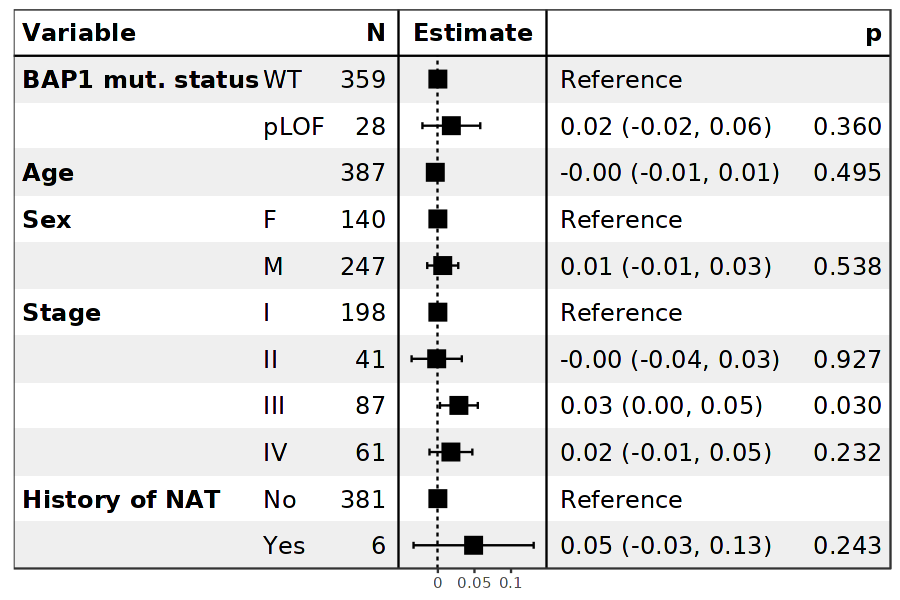

In [ ]:
options(repr.plot.width = 7.5, repr.plot.height = 5)
tam_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
tam_regression


#### Monocytes

In [63]:
fit <- lm(kirc_merged$Monocyte ~ `BAP1 mut. status` + Age + Sex + Stage + `History of NAT`, data = kirc_merged)
kirc_monocyte_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = kirc_merged$Monocyte ~ `BAP1 mut. status` + Age + 
    Sex + Stage + `History of NAT`, data = kirc_merged)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10157 -0.04292 -0.00312  0.03589  0.18227 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             0.095437   0.005571  17.131   <2e-16 ***
`BAP1 mut. status`pLOF  0.006706   0.011669   0.575    0.566    
Age                    -0.002726   0.003002  -0.908    0.364    
SexM                    0.001050   0.006259   0.168    0.867    
StageII                -0.008574   0.010128  -0.847    0.398    
StageIII               -0.002844   0.007633  -0.373    0.710    
StageIV                -0.002520   0.008642  -0.292    0.771    
`History of NAT`Yes     0.006303   0.024238   0.260    0.795    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.05793 on 379 degrees of freedom
Multiple R-squared:  0.005076,	Adjusted R-

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


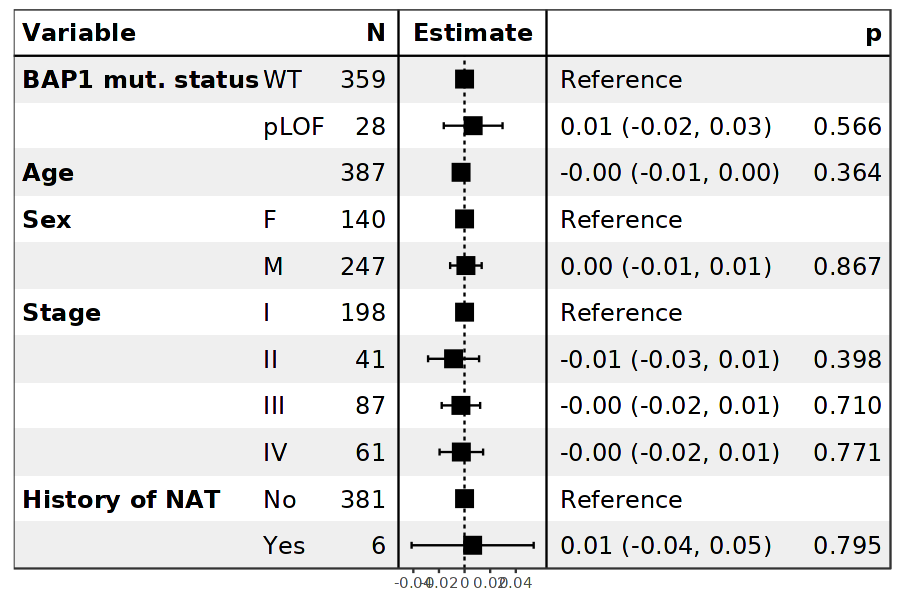

In [64]:
options(repr.plot.width = 7.5, repr.plot.height = 5)
mono_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
mono_regression


#### CD8s

In [65]:
fit <- lm(kirc_merged$CD8 ~ `BAP1 mut. status` + Age + Sex + Stage + `History of NAT`, data = kirc_merged)
kirc_cd8_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = kirc_merged$CD8 ~ `BAP1 mut. status` + Age + Sex + 
    Stage + `History of NAT`, data = kirc_merged)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.05575 -0.03454 -0.01379  0.01417  0.22810 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             0.0458607  0.0047170   9.722   <2e-16 ***
`BAP1 mut. status`pLOF -0.0116311  0.0098801  -1.177    0.240    
Age                    -0.0009621  0.0025422  -0.378    0.705    
SexM                   -0.0075417  0.0052998  -1.423    0.156    
StageII                 0.0098649  0.0085757   1.150    0.251    
StageIII                0.0014893  0.0064625   0.230    0.818    
StageIV                 0.0098860  0.0073172   1.351    0.177    
`History of NAT`Yes    -0.0054337  0.0205221  -0.265    0.791    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.04905 on 379 degrees of freedom
Multiple R-squared:  0.01322,	Adjusted

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


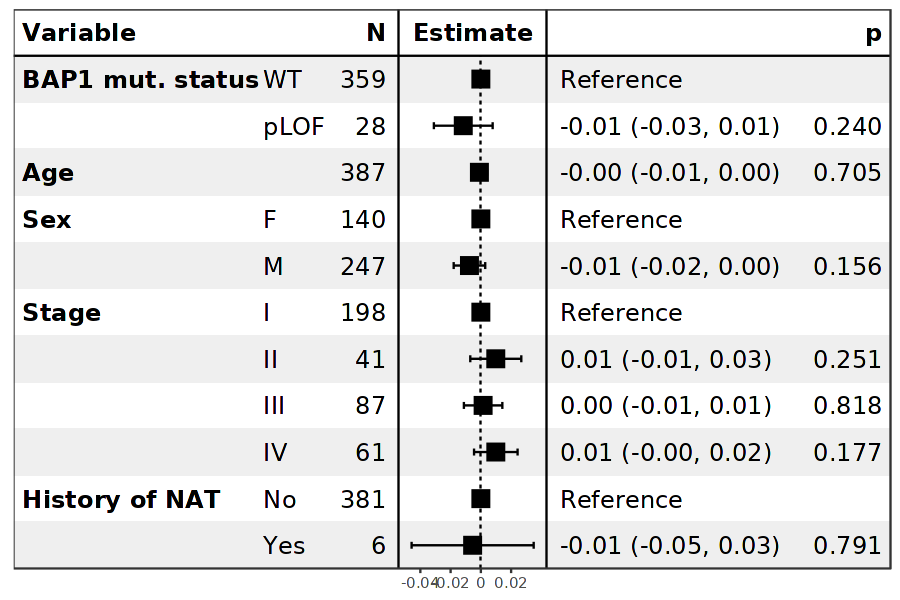

In [66]:
options(repr.plot.width = 7.5, repr.plot.height = 5)
cd8_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
cd8_regression


## JAV 101

### Load in JAV101 data
Contains cibersort results, mutation information, and clinical data

In [ ]:
jav101_merged <- readRDS("processed_data/JAV101_CIBERSORT_BAP1_clinical.rds")


Forest plot plotting params

In [72]:
panels <- list(
  list(width = 0.01),
  list(width = 0.18, display = ~variable, fontface = "bold", heading = "Variable"),
  list(width = 0.1, display = ~level),
  list(width = 0.05, display = ~n, hjust = 1, heading = "N"),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(
    width = 0.15, item = "forest", hjust = 0.5, heading = "Estimate", linetype = "dashed",
    line_x = 0
  ),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(width = 0.12, display = ~ ifelse(reference, "Reference", sprintf(
    "%0.2f (%0.2f, %0.2f)",
    trans(estimate), trans(conf.low), trans(conf.high)
  )), display_na = NA),
  list(
    width = 0.075,
    display = ~ ifelse(reference, "", format.pval(p.value, digits = 1, nsmall = 3, eps = 0.001)),
    display_na = NA, hjust = 1, heading = "p"
  ),
  list(width = 0.01)
)


#### TAM

In [73]:
fit <- lm(jav101_merged$TAM ~ `BAP1 mut. status` + Age + Sex + `Tumor location`, data = jav101_merged)
jav101_tam_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = jav101_merged$TAM ~ `BAP1 mut. status` + Age + Sex + 
    `Tumor location`, data = jav101_merged)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.14951 -0.05147 -0.01198  0.04390  0.28971 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)              0.155323   0.008459  18.363  < 2e-16 ***
`BAP1 mut. status`pLOF   0.020712   0.009875   2.097   0.0365 *  
Age                     -0.003851   0.003292  -1.170   0.2427    
SexM                    -0.005355   0.007727  -0.693   0.4887    
`Tumor location`Primary -0.030914   0.006974  -4.433 1.16e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.07184 on 476 degrees of freedom
Multiple R-squared:  0.04943,	Adjusted R-squared:  0.04144 
F-statistic: 6.188 on 4 and 476 DF,  p-value: 7.354e-05


Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


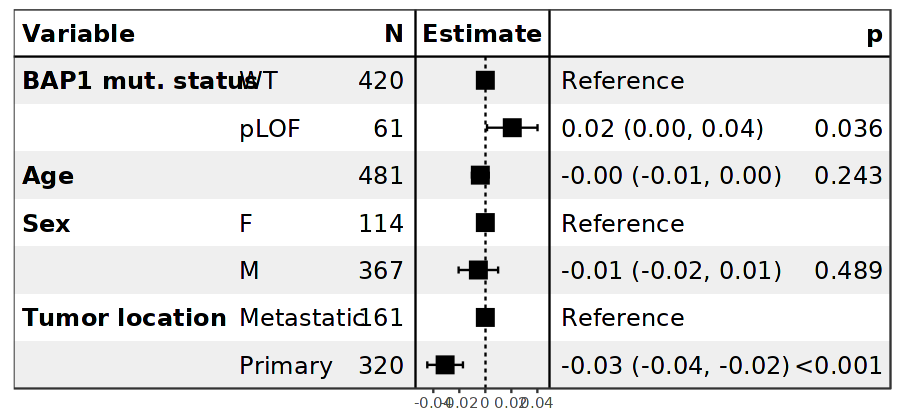

In [ ]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
tam_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
tam_regression


#### Monocytes

In [75]:
fit <- lm(jav101_merged$Monocyte ~ `BAP1 mut. status` + Age + Sex + `Tumor location`, data = jav101_merged)
jav101_monocyte_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = jav101_merged$Monocyte ~ `BAP1 mut. status` + Age + 
    Sex + `Tumor location`, data = jav101_merged)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.065158 -0.035376 -0.006206  0.024053  0.276445 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)              0.059668   0.005226  11.418  < 2e-16 ***
`BAP1 mut. status`pLOF   0.005905   0.006101   0.968  0.33360    
Age                     -0.004375   0.002034  -2.151  0.03196 *  
SexM                    -0.002967   0.004774  -0.622  0.53456    
`Tumor location`Primary -0.013132   0.004309  -3.048  0.00243 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.04438 on 476 degrees of freedom
Multiple R-squared:  0.02884,	Adjusted R-squared:  0.02068 
F-statistic: 3.534 on 4 and 476 DF,  p-value: 0.00743


Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


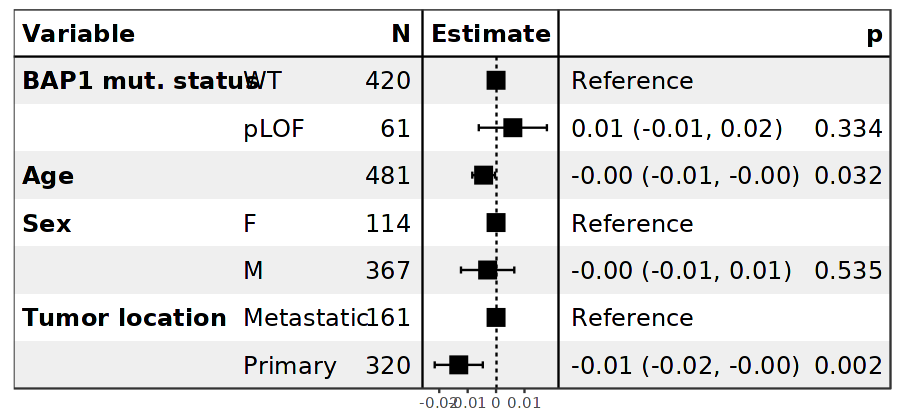

In [ ]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
mono_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
mono_regression


#### CD8s

In [77]:
fit <- lm(jav101_merged$CD8 ~ `BAP1 mut. status` + Age + Sex + `Tumor location`, data = jav101_merged)
jav101_cd8_coefficients <- summary(fit)$coefficients
summary(fit)



Call:
lm(formula = jav101_merged$CD8 ~ `BAP1 mut. status` + Age + Sex + 
    `Tumor location`, data = jav101_merged)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.029852 -0.019278 -0.012525  0.007098  0.202949 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)   
(Intercept)              0.0113026  0.0040006   2.825  0.00492 **
`BAP1 mut. status`pLOF   0.0093653  0.0046706   2.005  0.04551 * 
Age                     -0.0007365  0.0015571  -0.473  0.63646   
SexM                     0.0011598  0.0036547   0.317  0.75112   
`Tumor location`Primary  0.0072812  0.0032986   2.207  0.02777 * 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.03398 on 476 degrees of freedom
Multiple R-squared:  0.01992,	Adjusted R-squared:  0.01169 
F-statistic: 2.419 on 4 and 476 DF,  p-value: 0.04777


Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


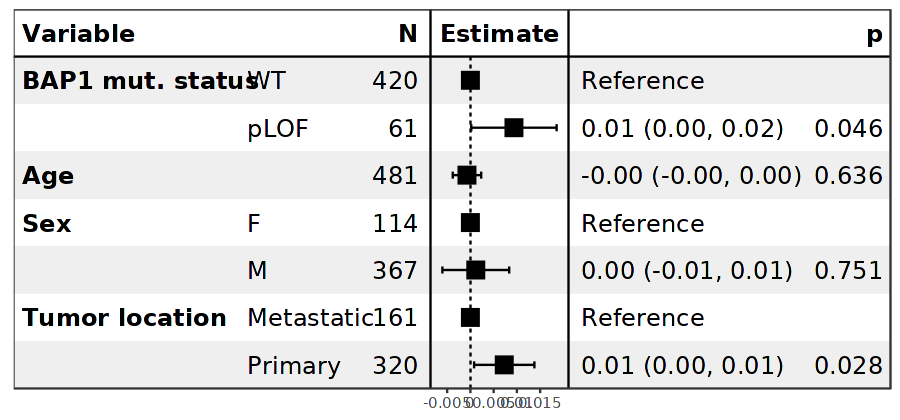

In [ ]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
cd8_regression <- forest_model(fit, exponentiate = FALSE, panels = panels)
cd8_regression


## Summary CIBERSORT analysis plot

In [79]:
summarize_model <- function(coeff_df, cell_type, cohort, BAP1_count) {
  # Extract coefficient and p-value from the dataframe
  summary_df <- data.frame(t(coeff_df["`BAP1 mut. status`pLOF", c("Estimate", "Pr(>|t|)", "Std. Error")]), check.names = F)

  # Add custom columns
  summary_df$cell_type <- cell_type
  summary_df$Cohort <- cohort
  summary_df$`Number of samples with\nBAP1 LOF mutation` <- BAP1_count
  summary_df$significant <- ifelse(summary_df[1, "Pr(>|t|)"] < 0.05, "Yes", "No")

  return(summary_df)
}


In [80]:
# Define the data frames and corresponding information
results_list <- list()

# For each dataframe, apply the summarize_model function
results_list[[1]] <- summarize_model(kirc_tam_coefficients, "TAM", "TCGA KIRC", 28)
results_list[[2]] <- summarize_model(kirc_monocyte_coefficients, "Monocyte", "TCGA KIRC", 28)
results_list[[3]] <- summarize_model(kirc_cd8_coefficients, "CD8", "TCGA KIRC", 28)

results_list[[4]] <- summarize_model(jav101_tam_coefficients, "TAM", "JAV101", 61)
results_list[[5]] <- summarize_model(jav101_monocyte_coefficients, "Monocyte", "JAV101", 61)
results_list[[6]] <- summarize_model(jav101_cd8_coefficients, "CD8", "JAV101", 61)

# Combine all the results into a single data frame
final_results_df <- do.call(rbind, results_list)

# Calculate lower and upper bounds for the error bars (95% CI)
final_results_df$lower <- final_results_df$Estimate - 1.96 * final_results_df[, "Std. Error"]
final_results_df$upper <- final_results_df$Estimate + 1.96 * final_results_df[, "Std. Error"]


In [81]:
final_results_df$Cohort <- factor(final_results_df$Cohort, levels = c("TCGA KIRC", "JAV101"))
final_results_df$cell_type <- factor(final_results_df$cell_type, levels = c("Monocyte", "TAM", "CD8"))

final_results_df <- final_results_df %>% mutate(cell_type = recode(cell_type,
    "CD8" = "CD8 T cell"
))


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


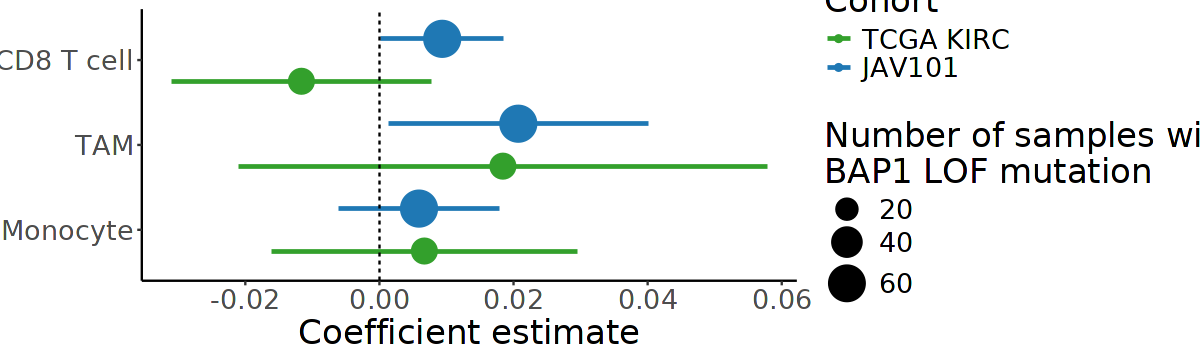

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 3)

# Plotting
ggplot(final_results_df, aes(x = Estimate, y = cell_type, color = Cohort)) +
  geom_point(aes(size = `Number of samples with\nBAP1 LOF mutation`), position = position_dodge(width = 1)) + # Only scale points here
  geom_linerange(aes(xmin = lower, xmax = upper), position = position_dodge(width = 1), size = 1) +
  scale_color_manual(values = c("TCGA KIRC" = "#33a02c", "JAV101" = "#1f78b4")) +
  scale_size_area(name = "Number of samples with\nBAP1 LOF mutation", breaks = c(20, 40, 60), max_size = 10, limits = c(20, 65)) + # Adjust point size range here
  geom_vline(xintercept = 0, linetype = "dashed") +
  theme_classic() +
  theme(
    text = element_text(size = 20),
    axis.title.y = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank()
  ) +
  labs(
    x = "Coefficient estimate"
  )


# Figure S5K: CD8+ feature density between BAP1 mut and wt tumors using multiplex IF data (restricted to IO exposed samples)

In [ ]:
mif_df <- read.table("processed_data/mIF_data.csv", sep = ",", check.names = F, header = T)


## Remove outliers

In [41]:
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI"
)

# Store which features each sample is an outlier for
sample_outlier_features <- list()

for (feature in features) {
  q1 <- quantile(mif_df[[feature]], 0.25, na.rm = TRUE)
  q3 <- quantile(mif_df[[feature]], 0.75, na.rm = TRUE)
  iqr <- q3 - q1
  upper_bound <- q3 + 5 * iqr
  lower_bound <- q1 - 5 * iqr

  # Find outlier samples for this feature
  extreme <- mif_df %>%
    dplyr::filter((.data[[feature]] > upper_bound) | (.data[[feature]] < lower_bound))

  for (sample_id in extreme$IP_Sample_ID) {
    sample_outlier_features[[as.character(sample_id)]] <-
      c(sample_outlier_features[[as.character(sample_id)]], feature)
  }
}

# Print samples that are outliers in more than one feature
for (sample in names(sample_outlier_features)) {
  feature_list <- sample_outlier_features[[sample]]
  if (length(feature_list) > 1) {
    cat(sprintf(
      "Sample %s is an outlier in %d features: %s\n",
      sample, length(feature_list), paste(feature_list, collapse = ", ")
    ))
  }
}


Sample CBIO_IP_P1558_S1 is an outlier in 4 features: CD8+ in IT, CD8+ in TSI, CD8+PD1+ in IT, CD8+PD1+ in TSI


In [42]:
mif_df <- mif_df %>% dplyr::filter(IP_Sample_ID != "CBIO_IP_P1558_S1")


## Normalize PD1+CD8+ by CD8+ density

In [43]:
mif_df$`CD8+PD1+_CD8+_IT_ratio` <- mif_df$`CD8+PD1+ in IT` / mif_df$`CD8+ in IT`
mif_df$`CD8+PD1+_CD8+_TSI_ratio` <- mif_df$`CD8+PD1+ in TSI` / mif_df$`CD8+ in TSI`


## Subset to IO exposed

In [44]:
ccrcc_mif_df <- mif_df %>%
  dplyr::filter(
    `IP Cancer Type Detailed` == "Renal Clear Cell Carcinoma" |
      RCC_manual_subtype_annotation == "Renal Clear Cell Carcinoma",
    `IO exposure` == "Yes"
  )


## Nominal and adjusted p values

In [45]:
# features to test
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI",
  "CD8+PD1+_CD8+_IT_ratio", "CD8+PD1+_CD8+_TSI_ratio"
)

# compute one-sided Wilcoxon (LOF > WT) p-values per feature
pvals <- sapply(features, function(f) {
  mutated <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "LOF"])
  wt <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "WT"])
  if (length(mutated) > 0 && length(wt) > 0) {
    wilcox.test(mutated, wt, alternative = "greater", exact = FALSE)$p.value
  } else {
    NA_real_
  }
})

# multiple testing correction (Benjamini–Hochberg / FDR)
pvals_adj <- p.adjust(pvals, method = "BH")

# results table sorted by raw p-value
results_df <- data.frame(
  feature = features,
  pval = as.numeric(pvals),
  pval_adj = as.numeric(pvals_adj),
  stringsAsFactors = FALSE
)

results_df <- results_df[order(results_df$pval), ]
results_df


,feature,pval,pval_adj
,<chr>,<dbl>,<dbl>
6,CD8+PD1+_CD8+_TSI_ratio,0.02623975,0.07592696
3,CD8+PD1+ in IT,0.03796348,0.07592696
5,CD8+PD1+_CD8+_IT_ratio,0.03796348,0.07592696
4,CD8+PD1+ in TSI,0.09228628,0.13842941
1,CD8+ in IT,0.13594936,0.16313923
2,CD8+ in TSI,0.17916323,0.17916323


Plotting function

In [ ]:
# Nice y-axis labels per row
ylab_lookup <- c(
  "CD8+ in IT" = "CD8+",
  "CD8+ in TSI" = "CD8+",
  "CD8+PD1+ in IT" = "CD8+PD1+",
  "CD8+PD1+ in TSI" = "CD8+PD1+",
  "CD8+PD1+_CD8+_IT_ratio" = "CD8+PD1+ / CD8+",
  "CD8+PD1+_CD8+_TSI_ratio" = "CD8+PD1+ / CD8+"
)

# Helper to build ONE panel
make_panel <- function(feat, show_y = TRUE, show_x = FALSE, show_legend = FALSE) {
  df_sub <- plot_df %>% dplyr::filter(feature == feat)

  # per-panel y position & label from q-values (results_df$pval_adj)
  y_max <- suppressWarnings(max(df_sub$value, na.rm = TRUE))
  y_pos <- if (is.finite(y_max)) y_max * 1.08 else NA_real_

  qv <- results_df %>%
    dplyr::filter(feature == feat) %>%
    summarise(pval_adj = if (n() == 0) NA_real_ else pval_adj[1]) %>%
    pull(pval_adj)
  lab <- sprintf("q=%.2g", ifelse(is.na(qv), 1, qv))

  pval_annot <- tibble::tibble(
    label = lab,
    group1 = "LOF",
    group2 = "WT",
    y_pos = y_pos
  )

  p <- ggplot(df_sub, aes(x = bap1_status, y = value)) +
    geom_boxplot(aes(fill = bap1_status),
      outlier.shape = NA, color = "black",
      na.rm = TRUE, show.legend = FALSE
    ) +
    scale_fill_manual(values = c(LOF = "#636464", WT = "white")) +
    ggnewscale::new_scale_fill() +
    geom_point(
      aes(shape = lymphoid, fill = io_exposed),
      position = position_jitter(width = 0.12, height = 0, seed = 123),
      size = 3, stroke = 0.2, color = "black", na.rm = TRUE,
      show.legend = show_legend
    ) +
    scale_shape_manual(values = c("Lymph node biopsy" = 24, "Other biopsy site" = 21)) +
    scale_fill_manual(values = c("IO exposed" = "red", "IO naïve" = "white")) +
    ggpubr::stat_pvalue_manual(
      data = pval_annot,
      label = "label", xmin = "group1", xmax = "group2",
      y.position = "y_pos",
      bracket.size = 0.3, size = 4.5, inherit.aes = FALSE
    ) +
    labs(
      x = if (show_x) "BAP1 Status" else NULL,
      y = if (show_y) ylab_lookup[[feat]] else NULL
    ) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
    theme_bw() +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major = element_blank(),
      panel.border = element_blank(),
      axis.line = element_line(color = "black"),
      axis.title.y = if (show_y) element_text() else element_blank(),
      axis.text.y = if (show_y) element_text() else element_blank(),
      axis.ticks.y = if (show_y) element_line() else element_blank(),
      axis.title.x = if (show_x) element_text() else element_blank(),
      axis.text.x = if (show_x) element_text() else element_blank(),
      axis.ticks.x = if (show_x) element_line() else element_blank(),
      legend.position = if (show_legend) "right" else "none",
      text = element_text(size = 14)
    )
  p
}


## Plot

Warning message in get_plot_component(plot, "guide-box"):
"Multiple components found; returning the first one. To return all, use `return_all = TRUE`."


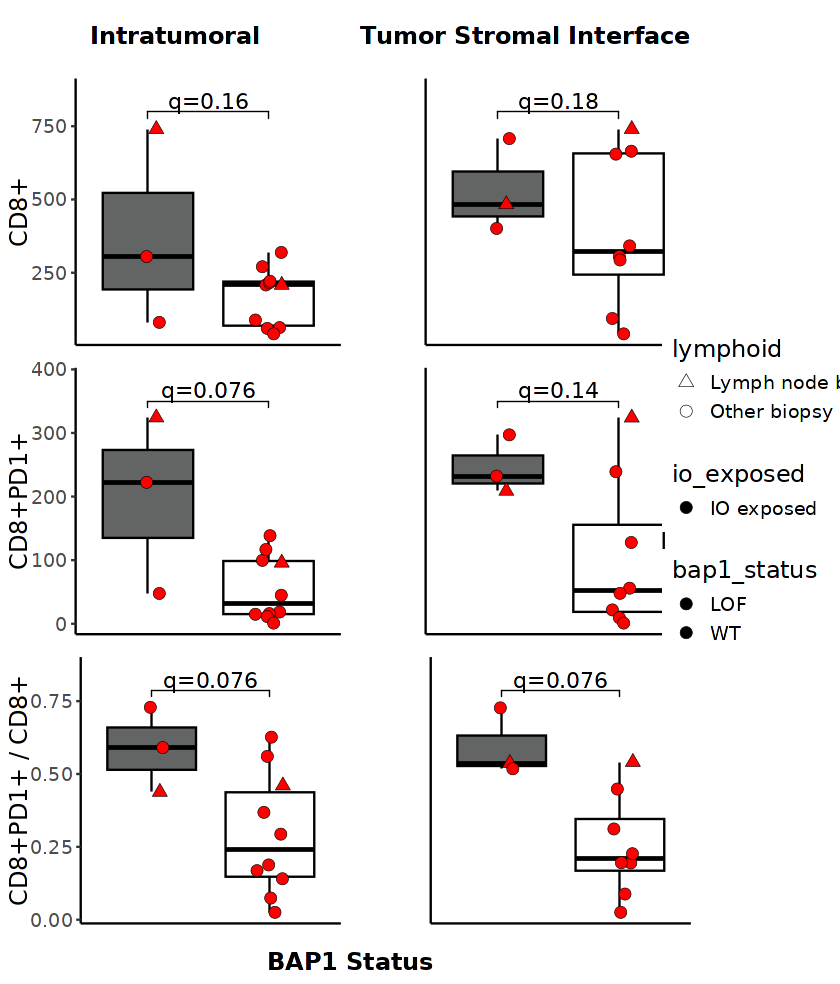

In [ ]:
plot_df <- ccrcc_mif_df %>%
  mutate(
    bap1_status = factor(bap1_status, levels = c("LOF", "WT")),
    lymphoid = factor(
      ifelse(`IP Oncotree Biopsy Site` == "LYMPHOID", "Lymph node biopsy", "Other biopsy site"),
      levels = c("Lymph node biopsy", "Other biopsy site")
    ),
    io_exposed = factor(
      ifelse(`IO exposure` == "Yes", "IO exposed", "IO naïve"),
      levels = c("IO exposed", "IO naïve")
    )
  ) %>%
  pivot_longer(all_of(features), names_to = "feature", values_to = "value")

# turn off x-axis labels in make_panel (no show_x arg needed anymore)
p1 <- make_panel("CD8+ in IT", show_y = TRUE, show_x = FALSE)
p2 <- make_panel("CD8+ in TSI", show_y = FALSE, show_x = FALSE)
p3 <- make_panel("CD8+PD1+ in IT", show_y = TRUE, show_x = FALSE)
p4 <- make_panel("CD8+PD1+ in TSI", show_y = FALSE, show_x = FALSE)
p5 <- make_panel("CD8+PD1+_CD8+_IT_ratio", show_y = TRUE, show_x = FALSE)
p6 <- make_panel("CD8+PD1+_CD8+_TSI_ratio", show_y = FALSE, show_x = FALSE)
p6_with_legend <- make_panel("CD8+PD1+_CD8+_TSI_ratio",
  show_y = FALSE, show_x = TRUE, show_legend = TRUE
)
legend_grob <- cowplot::get_legend(p6_with_legend)
# build the 3×2 grid
grid_3x2 <- plot_grid(
  plot_grid(p1, p2, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p3, p4, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p5, p6, ncol = 2, align = "hv", axis = "lrtb"),
  ncol = 1, align = "v", axis = "lrtb"
)

# add column headers (unchanged)
column_titles <- plot_grid(
  ggdraw() + draw_label("Intratumoral", fontface = "bold", hjust = 0.5, size = 14),
  ggdraw() + draw_label("Tumor Stromal Interface", fontface = "bold", hjust = 0.5, size = 14),
  ncol = 2
)

grid_with_titles <- plot_grid(column_titles, grid_3x2,
  ncol = 1, rel_heights = c(0.08, 1)
)

# add a shared x-axis label underneath
grid_with_xlabel <- plot_grid(
  grid_with_titles,
  ggdraw() + draw_label("BAP1 Status", fontface = "bold", size = 14, hjust = 0.5),
  ncol = 1, rel_heights = c(1, 0.05)
)

# combine with legend
final_plot <- plot_grid(grid_with_xlabel, legend_grob,
  ncol = 2, rel_widths = c(1, 0.2)
)


options(repr.plot.width = 7, repr.plot.height = 8.2)
print(final_plot)


# Figure S5L: CD8+ feature density between BAP1 mut and wt tumors using multiplex IF data (keep one non-ccrcc RCC sample that has a BAP1 mutation)

## Keep samples that are ccRCC or have BAP1 mutation

In [47]:
ccrcc_mif_df <- mif_df %>%
  dplyr::filter(
    `IP Cancer Type Detailed` == "Renal Clear Cell Carcinoma" |
      RCC_manual_subtype_annotation == "Renal Clear Cell Carcinoma" |
      bap1_status == "LOF"
  )


## Calculate nominal and adjusted p-values

In [48]:
# features to test
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI",
  "CD8+PD1+_CD8+_IT_ratio", "CD8+PD1+_CD8+_TSI_ratio"
)

# compute one-sided Wilcoxon (LOF > WT) p-values per feature
pvals <- sapply(features, function(f) {
  mutated <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "LOF"])
  wt <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "WT"])
  if (length(mutated) > 0 && length(wt) > 0) {
    wilcox.test(mutated, wt, alternative = "greater", exact = FALSE)$p.value
  } else {
    NA_real_
  }
})

# multiple testing correction (Benjamini–Hochberg / FDR)
pvals_adj <- p.adjust(pvals, method = "BH")

# results table sorted by raw p-value
results_df <- data.frame(
  feature = features,
  pval = as.numeric(pvals),
  pval_adj = as.numeric(pvals_adj),
  stringsAsFactors = FALSE
)

results_df <- results_df[order(results_df$pval), ]
results_df


,feature,pval,pval_adj
,<chr>,<dbl>,<dbl>
3,CD8+PD1+ in IT,0.004711243,0.02826746
5,CD8+PD1+_CD8+_IT_ratio,0.018508410,0.05545079
1,CD8+ in IT,0.027725395,0.05545079
6,CD8+PD1+_CD8+_TSI_ratio,0.037780284,0.05667043
4,CD8+PD1+ in TSI,0.048600544,0.05832065
2,CD8+ in TSI,0.096258786,0.09625879


## Plot

Warning message in get_plot_component(plot, "guide-box"):
"Multiple components found; returning the first one. To return all, use `return_all = TRUE`."


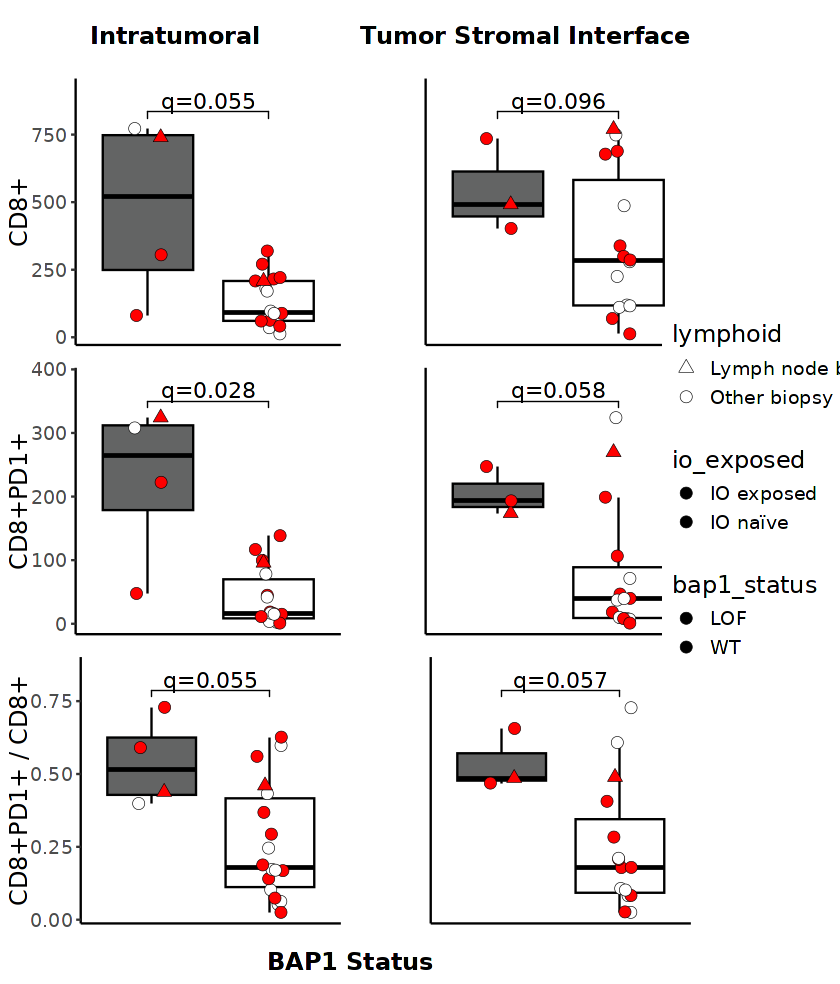

In [52]:
plot_df <- ccrcc_mif_df %>%
  mutate(
    bap1_status = factor(bap1_status, levels = c("LOF", "WT")),
    lymphoid = factor(
      ifelse(`IP Oncotree Biopsy Site` == "LYMPHOID", "Lymph node biopsy", "Other biopsy site"),
      levels = c("Lymph node biopsy", "Other biopsy site")
    ),
    io_exposed = factor(
      ifelse(`IO exposure` == "Yes", "IO exposed", "IO naïve"),
      levels = c("IO exposed", "IO naïve")
    )
  ) %>%
  pivot_longer(all_of(features), names_to = "feature", values_to = "value")


# turn off x-axis labels in make_panel (no show_x arg needed anymore)
p1 <- make_panel("CD8+ in IT", show_y = TRUE, show_x = FALSE)
p2 <- make_panel("CD8+ in TSI", show_y = FALSE, show_x = FALSE)
p3 <- make_panel("CD8+PD1+ in IT", show_y = TRUE, show_x = FALSE)
p4 <- make_panel("CD8+PD1+ in TSI", show_y = FALSE, show_x = FALSE)
p5 <- make_panel("CD8+PD1+_CD8+_IT_ratio", show_y = TRUE, show_x = FALSE)
p6 <- make_panel("CD8+PD1+_CD8+_TSI_ratio", show_y = FALSE, show_x = FALSE)
p6_with_legend <- make_panel("CD8+PD1+_CD8+_TSI_ratio",
  show_y = FALSE, show_x = TRUE, show_legend = TRUE
)
legend_grob <- cowplot::get_legend(p6_with_legend)
# build the 3×2 grid
grid_3x2 <- plot_grid(
  plot_grid(p1, p2, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p3, p4, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p5, p6, ncol = 2, align = "hv", axis = "lrtb"),
  ncol = 1, align = "v", axis = "lrtb"
)

# add column headers (unchanged)
column_titles <- plot_grid(
  ggdraw() + draw_label("Intratumoral", fontface = "bold", hjust = 0.5, size = 14),
  ggdraw() + draw_label("Tumor Stromal Interface", fontface = "bold", hjust = 0.5, size = 14),
  ncol = 2
)

grid_with_titles <- plot_grid(column_titles, grid_3x2,
  ncol = 1, rel_heights = c(0.08, 1)
)

# add a shared x-axis label underneath
grid_with_xlabel <- plot_grid(
  grid_with_titles,
  ggdraw() + draw_label("BAP1 Status", fontface = "bold", size = 14, hjust = 0.5),
  ncol = 1, rel_heights = c(1, 0.05)
)

# combine with legend
final_plot <- plot_grid(grid_with_xlabel, legend_grob,
  ncol = 2, rel_widths = c(1, 0.2)
)


options(repr.plot.width = 7, repr.plot.height = 8.2)
print(final_plot)


# Figure S5M: Coverage plots at immune evasion and checkpoint genes with increased accessibility in BAP1 mutated tumor cells
Significant DAGs between BAP1 pLOF and WT ccRCC tumor cells in supp table 5A

## Read in genes differentially accessible between BAP1 mutated and BAP1 wt ccrcc-balanced tumor cells and subset to those that are immune checkpoint and evasion genes. 

In [ ]:
dag <- readRDS("processed_data/ccrcc_balanced_bap1_DAGs.rds")

immune_evasion_and_checkpoints <- c(
  "CD274",
  "PDCD1LG2",
  "C10orf54",
  "LGALS9",
  "MIF",
  "VSIG4",
  "HLA-E",
  "NECTIN2",
  "PVR",
  "CD276",
  "NT5E",
  "ENTPD1",
  "VTCN1",
  "HLA-G",
  "IDO1"
)

sig_imm_dags <- dag %>% filter(cluster == "pLOF", gene %in% immune_evasion_and_checkpoints, p_val_adj < 0.05)


## Read in downsampled tumor cell object and make coverage plots

*Note: Created in `manuscript-figure5.ipynb`*

ccrcc-balanced tumor cells from late stage ccRCC patients, BAP1 WT or with pLOF mutation. Downsampled to max 1000 tumor cells per sample. 

In [ ]:
ccrcc_downsample <- readRDS("processed_data/ccrcc_balanced_bap1_mut_wt_latestage_downsamplebiopsy1000.rds")


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_segment()`)."


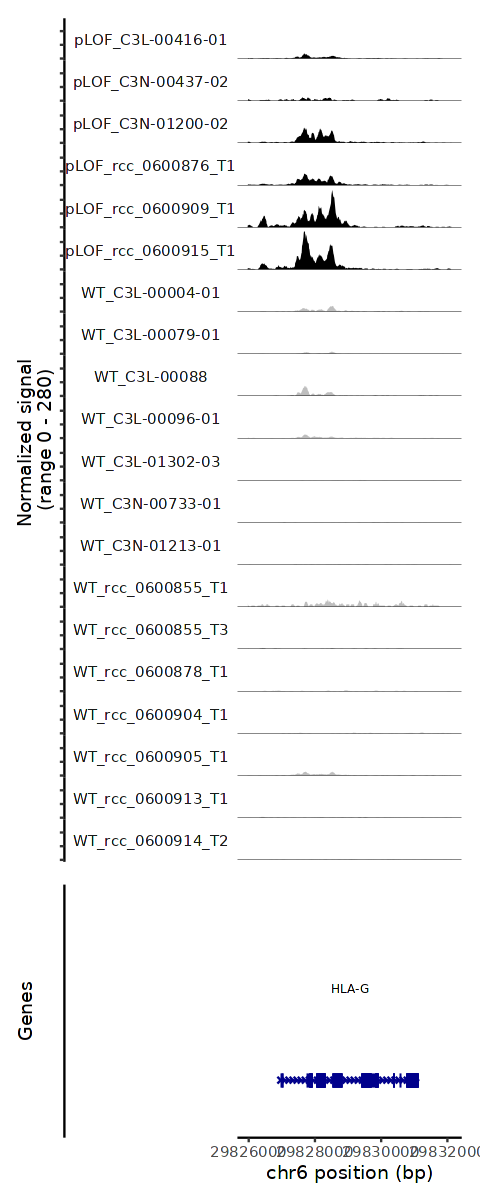

Warning message:
"Removed 373 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


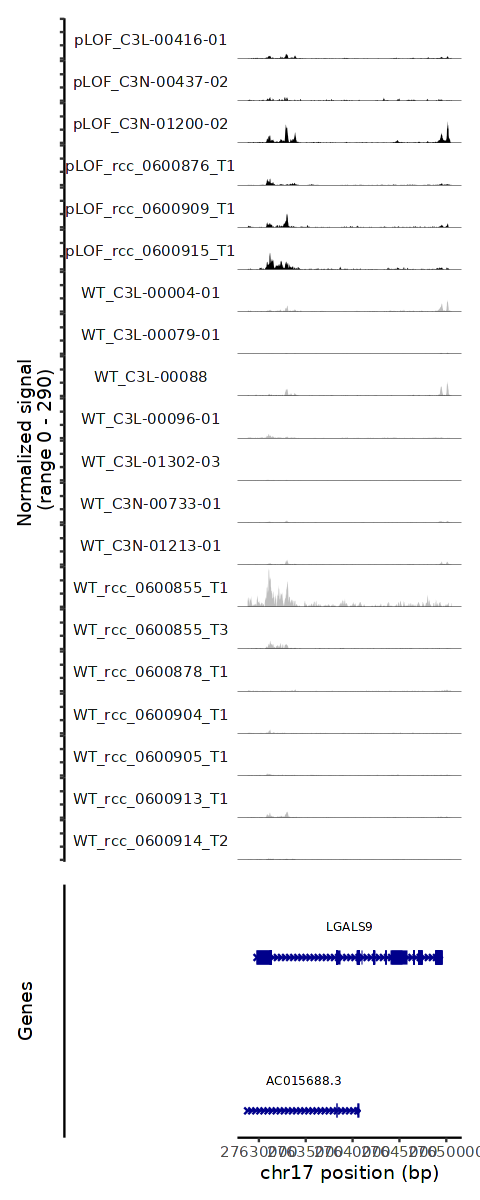

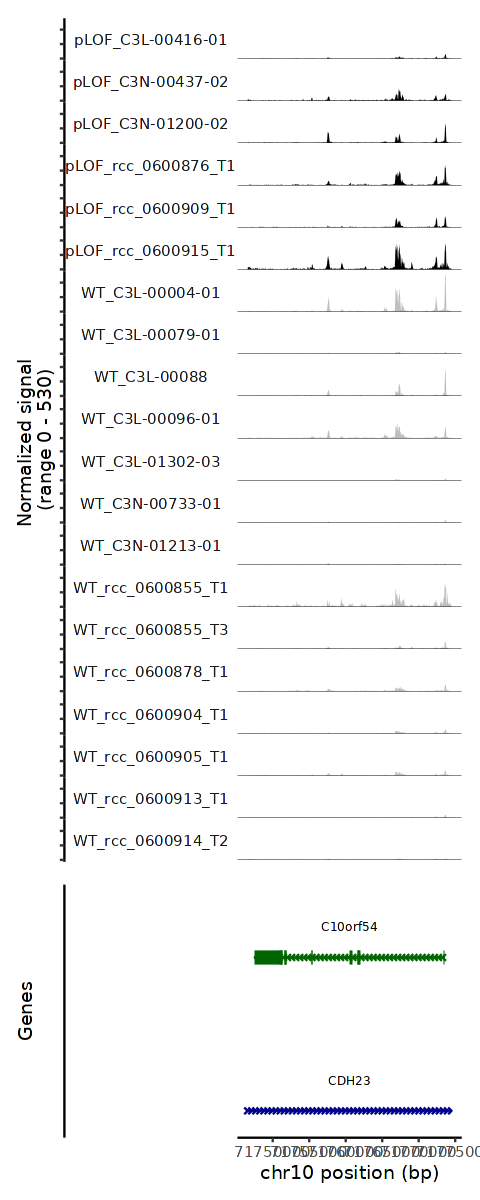

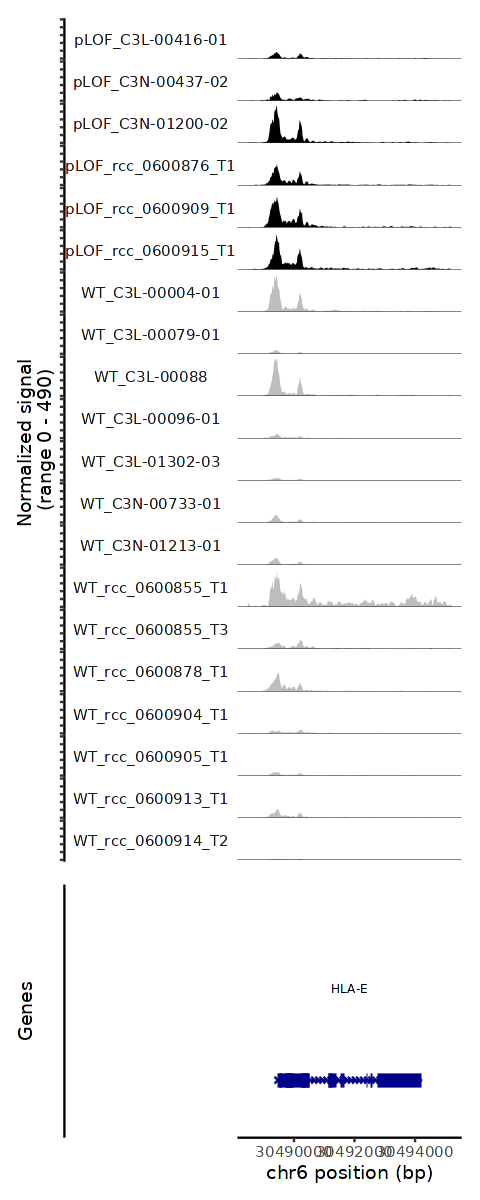

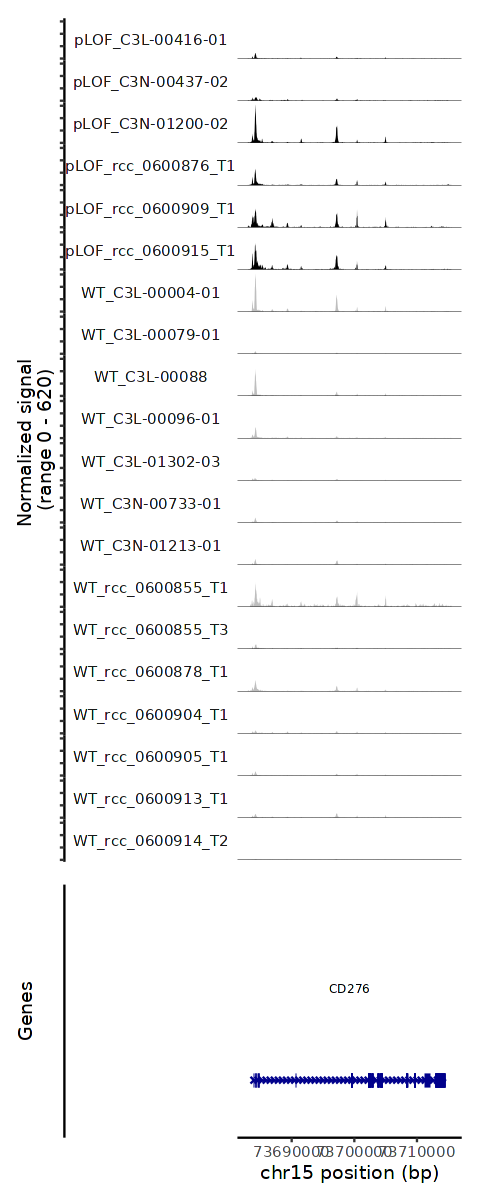

In [28]:
sig_imm_dags_genes <- sig_imm_dags$gene
for (gene in sig_imm_dags_genes) {
    DefaultAssay(ccrcc_downsample) <- "ATAC"
    options(repr.plot.width = 4, repr.plot.height = 10)
    plot <- CoveragePlot(ccrcc_downsample, region = gene, peaks = F, group.by = "biopsy", split.by = "BAP1", extend.upstream = 1000, extend.downstream = 1000) & scale_fill_manual(values = c(rep("black", 6), rep("grey", 14)))
    print(plot)
}


# Figure S5N: Chromatin accessibility profile correlations between samples from the same specimen

In [83]:
ccrcc <- readRDS("processed_data/ccrcc_balanced_seurat.rds")


Computes a sample–sample correlation heatmap for biopsies that have at least 2 samples. Optionally labels cells with correlation values.

In [ ]:
heatmap_same_biopsy <- function(
    obj,
    cohort_value = NULL, cohort_col = "cohort",
    assay_use = "ATAC", slot_use = "data",
    min_cells_per_sample = 0,
    min_frac = 0.05, max_frac = 0.95,
    min_mean = NULL,
    zscore_peaks = TRUE,
    # label options
    label_cells = TRUE,
    label_triangle = c("upper", "lower", "all", "none"),
    label_within_only = FALSE,
    label_format = "%.2f",
    fontsize_number = 8,
    number_color = "black",
    # color options
    biopsy_colors = c("#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f")) {
  label_triangle <- match.arg(label_triangle)

  # ---- pull metadata and optionally filter by cohort ----
  stopifnot(assay_use %in% names(obj@assays))
  meta_all <- obj@meta.data %>%
    as.data.frame() %>%
    mutate(cell = rownames(obj@meta.data))

  # if user wants a particular cohort, keep only those cells
  if (!is.null(cohort_value)) {
    stopifnot(cohort_col %in% colnames(meta_all))
    meta_all <- meta_all %>% filter(.data[[cohort_col]] == cohort_value)
    if (nrow(meta_all) == 0) {
      warning(sprintf("No cells for cohort '%s'.", cohort_value))
      return(invisible(NULL))
    }
  }

  # ---- optionally drop samples with too few cells ----
  if (min_cells_per_sample > 0) {
    keep_samples <- names(which(table(meta_all$sample) >= min_cells_per_sample))
    meta_all <- meta_all %>% filter(sample %in% keep_samples)
  }

  # ---- identify biopsies that have ≥2 samples (these are the only ones we can compare) ----
  sample_by_biopsy <- meta_all %>%
    distinct(sample, biopsy) %>%
    mutate(sample = as.character(sample), biopsy = as.character(biopsy))

  multi_bx <- sample_by_biopsy %>%
    filter(!is.na(biopsy), !is.na(sample)) %>%
    group_by(biopsy) %>%
    summarise(n_samples = dplyr::n(), .groups = "drop") %>%
    filter(n_samples >= 2)

  samples_keep <- sample_by_biopsy %>%
    semi_join(multi_bx, by = "biopsy") %>%
    distinct(sample) %>%
    pull()

  if (length(samples_keep) < 2) {
    warning("No biopsies with ≥2 samples after filtering.")
    return(invisible(NULL))
  }

  # ---- extract assay matrix and compute per-sample averages ----
  # For each sample, take all its cells and compute the mean accessibility per peak.
  mat <- GetAssayData(obj, assay = assay_use, slot = slot_use)
  cells_by_sample <- lapply(samples_keep, function(s) meta_all$cell[meta_all$sample == s])
  names(cells_by_sample) <- samples_keep

  sample_mat <- do.call(cbind, lapply(cells_by_sample, function(cells) {
    if (length(cells) == 1) {
      # if sample only has one cell, just take that column directly
      as.numeric(mat[, cells, drop = FALSE])
    } else {
      Matrix::rowMeans(mat[, cells, drop = FALSE])
    }
  }))
  colnames(sample_mat) <- samples_keep

  # ---- filter peaks based on accessibility fraction and mean ----
  binary <- (sample_mat > 0) * 1
  frac_accessible <- rowSums(binary) / ncol(sample_mat)
  keep_idx <- which(frac_accessible >= min_frac & frac_accessible <= max_frac)

  if (!is.null(min_mean)) {
    mns <- Matrix::rowMeans(sample_mat)
    keep_idx <- intersect(keep_idx, which(mns > min_mean))
  }

  sample_mat_filt <- sample_mat[keep_idx, , drop = FALSE]

  # ---- optionally z-score each peak across samples ----
  if (zscore_peaks) {
    mu <- Matrix::rowMeans(sample_mat_filt)
    xc <- sample_mat_filt - mu
    v <- Matrix::rowMeans(xc^2)
    sd <- sqrt(v)
    sd[sd == 0] <- 1
    sample_mat_filt <- xc / sd
  }

  # ---- compute sample–sample correlation matrix ----
  cor_mat <- cor(as.matrix(sample_mat_filt), method = "pearson", use = "pairwise.complete.obs")

  # ---- order samples by biopsy grouping for cleaner heatmap blocks ----
  ordering_df <- sample_by_biopsy %>%
    filter(sample %in% colnames(cor_mat)) %>%
    arrange(biopsy, sample)

  ord <- ordering_df$sample
  cor_mat <- cor_mat[ord, ord]

  # figure out where to draw the biopsy separation bars in heatmap
  blk_sizes <- ordering_df %>%
    dplyr::count(biopsy, name = "block_n") %>%
    pull(block_n)
  gap_pos <- if (length(blk_sizes) > 1) cumsum(blk_sizes[-length(blk_sizes)]) else NULL

  # ---- build row/column annotations ----
  ann <- data.frame(biopsy = ordering_df$biopsy)
  if (!is.null(cohort_value)) ann$cohort <- cohort_value
  rownames(ann) <- ord

  biopsy_levels <- unique(ordering_df$biopsy)
  ann_colors <- list(
    biopsy = setNames(
      rep(biopsy_colors, length.out = length(biopsy_levels)),
      biopsy_levels
    )
  )
  if (!is.null(cohort_value)) {
    ann_colors$cohort <- setNames(
      RColorBrewer::brewer.pal(length(unique(ann$cohort)), "Set2"),
      unique(ann$cohort)
    )
  }

  # ---- optionally build text labels for the heatmap cells ----
  disp <- NULL
  if (label_cells && ncol(cor_mat) > 0) {
    lab <- matrix(sprintf(label_format, as.numeric(cor_mat)),
      nrow = nrow(cor_mat), ncol = ncol(cor_mat)
    )

    if (label_within_only) {
      # only label cells where both samples come from the same biopsy
      bx <- ordering_df$biopsy
      names(bx) <- ord
      same <- outer(ord, ord, function(a, b) bx[a] == bx[b])
      lab[!same] <- ""
    }

    # restrict labels to upper/lower triangle if requested
    if (label_triangle == "upper") lab[lower.tri(lab, diag = TRUE)] <- ""
    if (label_triangle == "lower") lab[upper.tri(lab, diag = TRUE)] <- ""
    if (label_triangle == "none") lab[, ] <- ""

    disp <- lab
  }

  # ---- draw heatmap ----
  # pheatmap returns a complex object, so we save it and also print it
  ph <- pheatmap(
    cor_mat,
    cluster_rows = FALSE, cluster_cols = FALSE,
    annotation_row = ann, annotation_col = ann,
    annotation_colors = ann_colors,
    gaps_row = gap_pos, gaps_col = gap_pos,
    show_rownames = TRUE, show_colnames = TRUE,
    main = "",
    display_numbers = disp,
    number_color = number_color,
    fontsize_number = fontsize_number
  )

  print(ph)

  # return useful objects for downstream debugging/analysis
  invisible(list(cor_mat = cor_mat, order = ord, peaks_kept = length(keep_idx), pheatmap = ph))
}


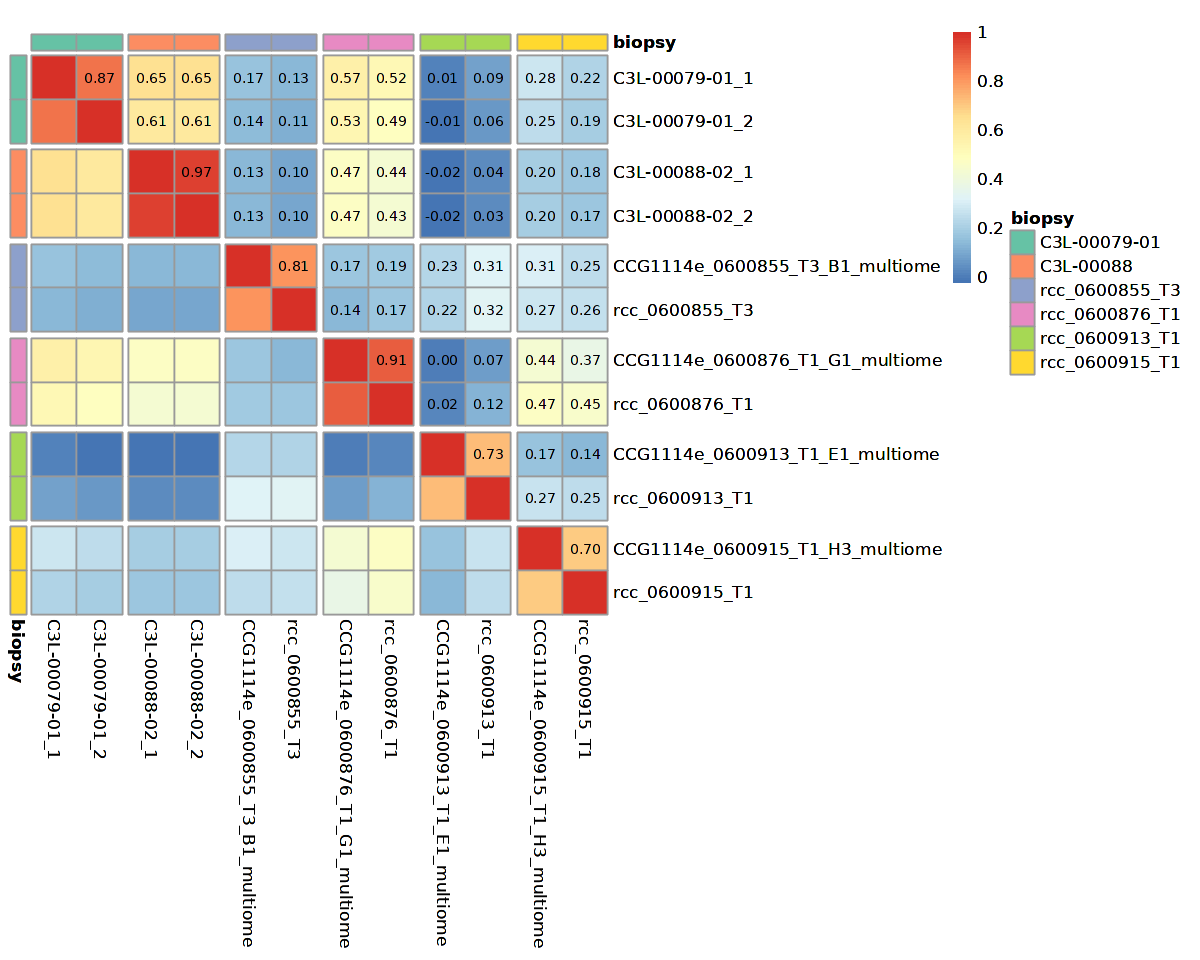

In [88]:
options(repr.plot.width = 10, repr.plot.height = 8)
heatmap_plot <- heatmap_same_biopsy(ccrcc,
  cohort_value = NULL,
  assay_use = "ATAC", slot_use = "data",
  min_cells_per_sample = 10, min_frac = 0.02, max_frac = 0.98, zscore_peaks = FALSE,
  label_cells = TRUE, label_triangle = "upper", label_within_only = FALSE, label_format = "%.2f"
)
